In [1]:
!pip list | grep torch

torch                                    2.10.0+cpu
torchao                                  0.10.0
torchaudio                               2.10.0+cpu
torchcodec                               0.10.0
torchdata                                0.11.0
torchsummary                             1.5.1
torchtune                                0.6.1
torchvision                              0.25.0+cpu


In [2]:
import torch

*   https://pytorch.org/blog/quantization-in-practice/
*   https://pytorch.org/docs/stable/quantization.html
*   https://pytorch.org/docs/stable/quantization-support.html

### Mapping function and Quantization Parameters

In [3]:
# r - float tensor, r' - int tensor
# S [scaling factor] = (beta - alpha) / (beta_q - alpha_q)
# Z [zero point] =  -(alpha / S - alpha_q)

def quantize(float_tensor, scale, z):
  # Q(r) = round(r/S + Z)
  return torch.round(float_tensor / scale + z)

def dequantize(int_tensor, scale, z):
  # r' = (Q(r) - Z) * S
  return (int_tensor - z) * scale

In [4]:
from torch.ao.quantization.observer import MinMaxObserver, MovingAverageMinMaxObserver, HistogramObserver

C, L = 3, 4
normal = torch.distributions.normal.Normal(0,1)
inputs = normal.sample((C, L))
print(inputs)

tensor([[ 1.8201,  0.4838, -1.1274,  2.2292],
        [-1.0598, -0.2413,  0.9700,  2.2341],
        [ 0.5295, -0.5834, -0.4933, -0.8456]])


In [5]:
observers = [MinMaxObserver(), MovingAverageMinMaxObserver(), HistogramObserver()]
for obs in observers:
  obs(inputs)
  print(obs.__class__.__name__, obs.calculate_qparams())

MinMaxObserver (tensor([0.0132]), tensor([86], dtype=torch.int32))
MovingAverageMinMaxObserver (tensor([0.0132]), tensor([86], dtype=torch.int32))
HistogramObserver (tensor([0.0132]), tensor([86], dtype=torch.int32))


In [6]:
scale, z = observers[0].calculate_qparams()
reconstruction_error = torch.abs(dequantize(quantize(inputs, scale, z), scale, z) - inputs)
reconstruction_error

tensor([[0.0009, 0.0040, 0.0063, 0.0014],
        [0.0052, 0.0040, 0.0055, 0.0063],
        [0.0022, 0.0034, 0.0056, 0.0019]])

### Affine and Symmetric Quantization Schemes

In [7]:
import numpy as np
import matplotlib.pyplot as plt


def get_symmetric_range(x):
  beta = torch.max(x.max(), x.min().abs())
  return -beta.item(), beta.item()

def get_affine_range(x):
  return x.min().item(), x.max().item()

def plot(plt, data, scheme):
  boundaries = get_affine_range(data) if scheme == 'affine' else get_symmetric_range(data)
  a, _, _ = plt.hist(data, density=True, bins=100)
  ymin, ymax = np.quantile(a[a>0], [0.25, 0.95])
  plt.vlines(x=boundaries, ls='--', colors='purple', ymin=ymin, ymax=ymax)

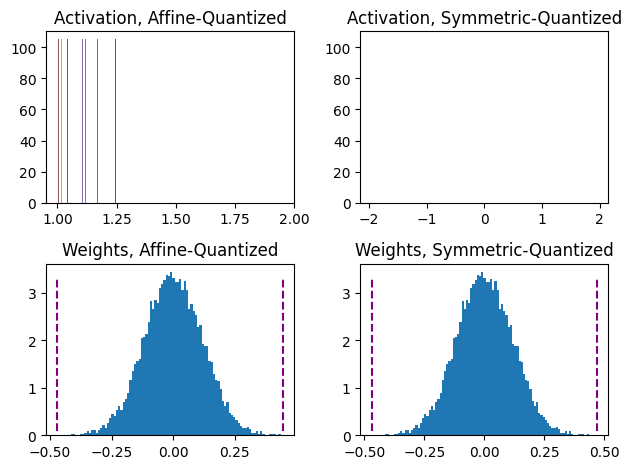

In [8]:
act =  torch.distributions.pareto.Pareto(1, 10).sample((1, 1024))
weights = torch.distributions.normal.Normal(0, 0.12).sample((3, 64, 7, 7)).flatten()

fig, axs = plt.subplots(2,2)
plot(axs[0, 0], act, 'affine')
axs[0, 0].set_title("Activation, Affine-Quantized")

plot(axs[0, 1], act, 'symmetric')
axs[0, 1].set_title("Activation, Symmetric-Quantized")

plot(axs[1, 0], weights, 'affine')
axs[1, 0].set_title("Weights, Affine-Quantized")

plot(axs[1, 1], weights, 'symmetric')
axs[1, 1].set_title("Weights, Symmetric-Quantized")

fig.tight_layout()
plt.show()

In [9]:
for qscheme in [torch.per_tensor_affine, torch.per_tensor_symmetric]:
  obs = MovingAverageMinMaxObserver(qscheme=qscheme)
  obs(inputs)
  print(f"Qscheme: {qscheme} | {obs.calculate_qparams()}")

Qscheme: torch.per_tensor_affine | (tensor([0.0132]), tensor([86], dtype=torch.int32))
Qscheme: torch.per_tensor_symmetric | (tensor([0.0175]), tensor([128]))


### Per-Tensor and Per-Channel Quantization Schemes

In [10]:
from torch.ao.quantization.observer import MovingAveragePerChannelMinMaxObserver

obs = MovingAveragePerChannelMinMaxObserver(ch_axis = 0)  # calculate qparams for all `C` channels separately
obs(inputs)
print(obs.calculate_qparams())

(tensor([0.0132, 0.0129, 0.0054]), tensor([ 86,  82, 157], dtype=torch.int32))


For weights quantization, symmetric-per-channel quantization provides better accuracies; per-tensor quantization performs poorly, possibly due to high variance in conv weights across channels from batchnorm folding.
[https://arxiv.org/abs/2004.09602]

https://github.com/pytorch/pytorch/blob/748d9d24940cd17938df963456c90fa1a13f3932/torch/ao/quantization/observer.py#L258

### Backend Engine

In [11]:
backend = 'fbgemm' #'fbgemm' if x86 else 'qnnpack' intel - oneDNN
qconfig = torch.ao.quantization.get_default_qconfig(backend)
torch.backends.quantized.engine = backend

GPUs - via TensorRT and cuDNN
https://pytorch.org/docs/stable/quantization.html#note-for-native-cpu-backends

### QConfig

In [12]:
my_qconfig = torch.ao.quantization.QConfig(
  activation=MovingAverageMinMaxObserver.with_args(qscheme=torch.per_tensor_affine),
  weight=MovingAveragePerChannelMinMaxObserver.with_args(qscheme=torch.qint8))

my_qconfig

QConfig(activation=functools.partial(<class 'torch.ao.quantization.observer.MovingAverageMinMaxObserver'>, qscheme=torch.per_tensor_affine){}, weight=functools.partial(<class 'torch.ao.quantization.observer.MovingAveragePerChannelMinMaxObserver'>, qscheme=torch.qint8){})

### Eager Mode v/s FX Graph Mode

*    Eager Mode Quantization is a beta feature. User needs to do fusion and specify where quantization and dequantization happens manually, also it only supports modules and not functionals.
*    FX Graph Mode Quantization is a new automated quantization framework in PyTorch, and currently it’s a prototype feature. It improves upon Eager Mode Quantization by adding support for functionals and automating the quantization process, although people might need to refactor the model to make the model compatible with FX Graph Mode Quantization (symbolically traceable with torch.fx)






FX Graph Mode automatically fuses eligible modules, inserts Quant/DeQuant stubs, calibrates the model and returns a quantized module - all in two method calls - but only for networks that are symbolic traceable. The examples below contain the calls using Eager Mode and FX Graph Mode for comparison.
https://pytorch.org/docs/stable/fx.html#torch.fx.symbolic_trace

In [13]:
def f(a, b):
    if b == True:
        return a
    else:
        return a * 2

In [14]:
traced_f = torch.fx.symbolic_trace(f, concrete_args={'b': False})
assert traced_f(3, False) == 6

https://pytorch.org/docs/stable/fx.html

### Post-Training Dynamic/Weight-only Quantization

Here the model’s weights are pre-quantized; the activations are quantized on-the-fly (“dynamic”) during inference. The simplest of all approaches, it has a one line API call in torch.quantization.quantize_dynamic. Currently only Linear and Recurrent (LSTM, GRU, RNN) layers are supported for dynamic quantization



*   Can result in higher accuracies since the clipping range is exactly calibrated for each input
*   Calibrating and quantizing the activations at each layer during runtime can add to the compute overhead



In [15]:
from torch import nn

# toy model
m = nn.Sequential(
  nn.Conv2d(2, 64, (8,)),
  nn.ReLU(),
  nn.Linear(16, 10),
  nn.LSTM(10, 10))

m.eval()

Sequential(
  (0): Conv2d(2, 64, kernel_size=(8,), stride=(1, 1))
  (1): ReLU()
  (2): Linear(in_features=16, out_features=10, bias=True)
  (3): LSTM(10, 10)
)

In [16]:
## EAGER MODE
from torch.ao.quantization import quantize_dynamic

model_quantized = quantize_dynamic(
    model=m, qconfig_spec={nn.LSTM, nn.Linear}, dtype=torch.qint8, inplace=False
)

/tmp/ipykernel_633/2181302342.py:4: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_quantized = quantize_dynamic(


In [17]:
## FX MODE
from torch.ao.quantization import quantize_fx

example_inputs = (torch.randn(1, 3, 224, 224),)
qconfig_dict = {"": torch.ao.quantization.default_dynamic_qconfig}  # An empty key denotes the default applied to all modules
model_prepared = quantize_fx.prepare_fx(m, qconfig_dict, example_inputs)
model_quantized = quantize_fx.convert_fx(model_prepared)

/tmp/ipykernel_633/15622409.py:6: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_prepared = quantize_fx.prepare_fx(m, qconfig_dict, example_inputs)
/usr/local/lib/python3.12/dist-packages/torch/ao/quantization/quantize_fx.py:146: FutureWarning: Passing a QConfig dictionary to prepare is deprecated and will not be supported in a future version. Please pass in a QConf

In [18]:
torch.ao.quantization.default_dynamic_qconfig

QConfig(activation=functools.partial(<class 'torch.ao.quantization.observer.PlaceholderObserver'>, dtype=torch.quint8, quant_min=0, quant_max=255, is_dynamic=True){}, weight=functools.partial(<class 'torch.ao.quantization.observer.MinMaxObserver'>, dtype=torch.qint8, qscheme=torch.per_tensor_symmetric){})

### Post-Training Static Quantization (PTQ)

PTQ also pre-quantizes model weights but instead of calibrating activations on-the-fly, the clipping range is pre-calibrated and fixed (“static”) using validation data. Activations stay in quantized precision between operations during inference. About 100 mini-batches of representative data are sufficient to calibrate the observers

*   Static quantization has faster inference than dynamic quantization because it eliminates the float<->int conversion costs between layers
*   Static quantized models may need regular re-calibration to stay robust against distribution-drift



In [19]:
# Static quantization of a model consists of the following steps:

#     Fuse modules
#     Insert Quant/DeQuant Stubs
#     Prepare the fused module (insert observers before and after layers)
#     Calibrate the prepared module (pass it representative data)
#     Convert the calibrated module (replace with quantized version)

import torch
from torch import nn
import copy

backend = "fbgemm"  # running on a x86 CPU. Use "qnnpack" if running on ARM.

model = nn.Sequential(
     nn.Conv2d(2, 64, 3),
     nn.ReLU(),
     nn.Conv2d(64, 128, 3),
     nn.ReLU()
)

In [20]:
## EAGER MODE
m = copy.deepcopy(model)
m.eval()

"""Fuse
- Inplace fusion replaces the first module in the sequence with the fused module, and the rest with identity modules
"""
torch.ao.quantization.fuse_modules(m, ['0','1'], inplace=True) # fuse first Conv-ReLU pair
torch.ao.quantization.fuse_modules(m, ['2','3'], inplace=True) # fuse second Conv-ReLU pair

"""Insert stubs"""
m = nn.Sequential(torch.ao.quantization.QuantStub(),
                  *m,
                  torch.ao.quantization.DeQuantStub())

"""Prepare"""
m.qconfig = torch.ao.quantization.get_default_qconfig(backend)
torch.ao.quantization.prepare(m, inplace=True)

"""Calibrate
- This example uses random data for convenience. Use representative (validation) data instead.
"""
with torch.inference_mode():
  for _ in range(10):
    x = torch.rand(1, 2, 28, 28)
    m(x)

"""Convert"""
torch.ao.quantization.convert(m, inplace=True)

"""Check"""
print(m[1].weight().element_size()) # 1 byte instead of 4 bytes for FP32

/tmp/ipykernel_633/213743822.py:18: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  torch.ao.quantization.prepare(m, inplace=True)
/usr/local/lib/python3.12/dist-packages/torch/ao/quantization/observer.py:1039: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTor

1


/tmp/ipykernel_633/213743822.py:29: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  torch.ao.quantization.convert(m, inplace=True)


In [21]:
m[1].weight()

tensor([[[[-0.1285, -0.2349, -0.1468],
          [-0.0459,  0.2257,  0.1523],
          [-0.1431, -0.1688,  0.0165]],

         [[-0.0661, -0.0385,  0.2331],
          [ 0.2092, -0.1542,  0.0275],
          [-0.0496, -0.2331, -0.0037]]],


        [[[ 0.0384, -0.1353, -0.1280],
          [-0.1444,  0.1298, -0.0512],
          [ 0.2321, -0.1974,  0.0676]],

         [[ 0.0932,  0.1152, -0.1956],
          [ 0.1846, -0.0768, -0.0219],
          [ 0.0439, -0.1718,  0.0311]]],


        [[[-0.0257,  0.1620, -0.0621],
          [ 0.1302, -0.1166,  0.0363],
          [ 0.0893,  0.0893, -0.1544]],

         [[ 0.1090, -0.0712,  0.0212],
          [ 0.1196,  0.1257, -0.1544],
          [ 0.0681, -0.0454,  0.1923]]],


        ...,


        [[[ 0.1016,  0.1034, -0.0707],
          [ 0.1106, -0.1070,  0.0762],
          [ 0.0871,  0.0580, -0.1542]],

         [[ 0.0345,  0.1088, -0.1070],
          [ 0.1034, -0.1179,  0.2303],
          [ 0.0181, -0.0109,  0.0490]]],


        [[[-0.1762,  0.03

In [22]:
## FX GRAPH
from torch.ao.quantization import quantize_fx

m = copy.deepcopy(model)
m.eval()
qconfig_dict = {"": torch.ao.quantization.get_default_qconfig(backend)}

# Prepare
example_inputs = (torch.randn(1, 3, 224, 224),)
model_prepared = quantize_fx.prepare_fx(m, qconfig_dict, example_inputs)

# Calibrate - Use representative (validation) data.
with torch.inference_mode():
  for _ in range(10):
    x = torch.rand(1, 2, 28, 28)
    model_prepared(x)

# quantize
model_quantized = quantize_fx.convert_fx(model_prepared)

/tmp/ipykernel_633/750729956.py:10: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_prepared = quantize_fx.prepare_fx(m, qconfig_dict, example_inputs)
/tmp/ipykernel_633/750729956.py:19: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.q

### SENSITIVITY ANALYSIS

In [23]:
# ONE-AT-A-TIME SENSITIVITY ANALYSIS

for quantized_layer, _ in model.named_modules():
  print("Only quantizing layer: ", quantized_layer)

  # The module_name key allows module-specific qconfigs.
  qconfig_dict = {"": None,
  "module_name":[(quantized_layer, torch.quantization.get_default_qconfig(backend))]}

  example_inputs = (torch.randn(1, 3, 224, 224),)
  model_prepared = quantize_fx.prepare_fx(model, qconfig_dict, example_inputs)
  # calibrate
  model_quantized = quantize_fx.convert_fx(model_prepared)
  # evaluate(model)

/tmp/ipykernel_633/1147990886.py:11: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_prepared = quantize_fx.prepare_fx(model, qconfig_dict, example_inputs)


Only quantizing layer:  
Only quantizing layer:  0


/tmp/ipykernel_633/1147990886.py:13: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_quantized = quantize_fx.convert_fx(model_prepared)
/usr/local/lib/python3.12/dist-packages/torch/ao/quantization/fx/convert.py:434: UserWarning: must run observer before calling calculate_qparams.                                    Returning default scale and zero point 
  scale, zer

Only quantizing layer:  1
Only quantizing layer:  2
Only quantizing layer:  3


 Numeric Suite - https://pytorch.org/tutorials/prototype/numeric_suite_tutorial.html

In [24]:
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
import os
import torch.ao.quantization
import torch.ao.ns._numeric_suite as ns
from torch.ao.quantization import (
    default_eval_fn,
    default_qconfig,
    quantize,
)

In [25]:
float_model = torchvision.models.quantization.resnet18(pretrained=True, quantize=False)
float_model.to('cpu')
float_model.eval()
float_model.fuse_model()
float_model.qconfig = torch.quantization.default_qconfig
img_data = (torch.rand(2, 3, 10, 10, dtype=torch.float), torch.randint(0, 1, (2,), dtype=torch.long))
qmodel = quantize(float_model, default_eval_fn, [[img_data]], inplace=False)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 148MB/s]
/tmp/ipykernel_633/409614095.py:7: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  qmodel = quantize(float_model, default_eval_fn, [[img_data]], inplace=False)


In [26]:
def compute_error(x, y):
    Ps = torch.norm(x)
    Pn = torch.norm(x - y)
    return 20 * torch.log10(Ps/Pn)

wt_compare_dict = ns.compare_weights(float_model.state_dict(), qmodel.state_dict())
for key in wt_compare_dict:
    print(key, compute_error(wt_compare_dict[key]['float'], wt_compare_dict[key]['quantized'].dequantize()))

print("---")

act_compare_dict = ns.compare_model_outputs(float_model, qmodel, img_data[0])
for key in act_compare_dict:
    print(key, compute_error(act_compare_dict[key]['float'][0], act_compare_dict[key]['quantized'][0].dequantize()))


conv1.weight tensor(31.6638)
layer1.0.conv1.weight tensor(30.6450)
layer1.0.conv2.weight tensor(31.1528)
layer1.1.conv1.weight tensor(32.1438)
layer1.1.conv2.weight tensor(31.2477)
layer2.0.conv1.weight tensor(30.9890)
layer2.0.conv2.weight tensor(28.8233)
layer2.0.downsample.0.weight tensor(31.5558)
layer2.1.conv1.weight tensor(30.7668)
layer2.1.conv2.weight tensor(28.4516)
layer3.0.conv1.weight tensor(30.9247)
layer3.0.conv2.weight tensor(26.6841)
layer3.0.downsample.0.weight tensor(28.7825)
layer3.1.conv1.weight tensor(28.9707)
layer3.1.conv2.weight tensor(25.6784)
layer4.0.conv1.weight tensor(26.8495)
layer4.0.conv2.weight tensor(25.8394)
layer4.0.downsample.0.weight tensor(28.6355)
layer4.1.conv1.weight tensor(26.8758)
layer4.1.conv2.weight tensor(28.4319)
fc._packed_params._packed_params tensor(32.6505)
---
conv1.stats tensor(37.6680, grad_fn=<MulBackward0>)
layer1.0.conv1.stats tensor(29.8461, grad_fn=<MulBackward0>)
layer1.0.conv2.stats tensor(28.5809, grad_fn=<MulBackward0>)
l

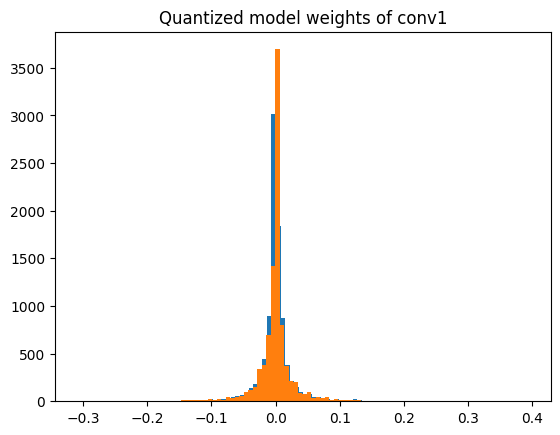

In [27]:
import matplotlib.pyplot as plt

f = wt_compare_dict['conv1.weight']['float'].flatten()
plt.hist(f, bins = 100)

q = wt_compare_dict['conv1.weight']['quantized'].flatten().dequantize()
plt.hist(q, bins = 100)
plt.title("Quantized model weights of conv1")
plt.show()

### RECOMMENDATIONS FOR YOUR WORKFLOW

![](https://drive.google.com/uc?export=view&id=1ij7GElwiKFNmJ221aKpkDRwMj5i-2DLh)



*   Large (10M+ parameters) models are more robust to quantization error
*   Quantizing a model from a FP32 checkpoint provides better accuracy than training an INT8 model from scratch
*   Dynamic Quantization is an easy first step, especially if your model has many Linear or Recurrent layers
*   Use symmetric-per-channel quantization with MinMax observers for quantizing weights. Use affine-per-tensor quantization with MovingAverageMinMax observers for quantizing activations
*   Use metrics like SQNR to identify which layers are most suscpetible to quantization error. Turn off quantization on these layers

Eager mode https://pytorch.org/docs/stable/quantization.html#eager-mode-quantization



*   https://pytorch.org/docs/stable/quantization.html#post-training-dynamic-quantization
*   https://pytorch.org/docs/stable/quantization.html#post-training-static-quantization


FX Graph https://pytorch.org/docs/stable/quantization.html#prototype-fx-graph-mode-quantization



*   https://pytorch.org/tutorials/prototype/fx_graph_mode_ptq_static.html
*   https://pytorch.org/tutorials/prototype/fx_graph_mode_ptq_dynamic.html





## New forkflow with torchao



In [28]:
!pip install torchao

In [29]:
import copy
import torch

class ToyLinearModel(torch.nn.Module):
    def __init__(self, m: int, n: int, k: int):
        super().__init__()
        self.linear1 = torch.nn.Linear(m, n, bias=False)
        self.linear2 = torch.nn.Linear(n, k, bias=False)

    def forward(self, x):
        x = self.linear1(x)
        x = self.linear2(x)
        return x

model = ToyLinearModel(1024, 1024, 1024).eval()

# Optional: compile model for faster inference and generation
model = torch.compile(model, mode="max-autotune", fullgraph=True)
model_f32 = copy.deepcopy(model)


In [30]:
from torchao.quantization import Int4DynamicActivationInt4WeightConfig, quantize_
quantize_(model, Int4DynamicActivationInt4WeightConfig())

In [31]:
from torchao.utils import (
    benchmark_model,
    unwrap_tensor_subclass,
)

num_runs = 100
torch._dynamo.reset()
example_inputs = (torch.randn(1, 1024, dtype=torch.float32),)
f32_time = benchmark_model(model_f32, num_runs, example_inputs)
int4_time = benchmark_model(model, num_runs, example_inputs)

print("f32 mean time: %0.3f ms" % f32_time)
print("int4 mean time: %0.3f ms" % int4_time)
print("speedup: %0.1fx" % (f32_time / int4_time))

f32 mean time: 0.170 ms
int4 mean time: 0.117 ms
speedup: 1.5x


In [32]:
import os
torch.save(model, "/tmp/int4_model.pt")
torch.save(model_f32, "/tmp/f32_model.pt")
int4_model_size_mb = os.path.getsize("/tmp/int4_model.pt") / 1024 / 1024
f32_model_size_mb = os.path.getsize("/tmp/f32_model.pt") / 1024 / 1024

print("int4 model size: %.2f MB" % int4_model_size_mb)

print("f32 model size: %.2f MB" % f32_model_size_mb)


int4 model size: 1.01 MB
f32 model size: 8.00 MB


### Neural Network Compression Framework (NNCF)

In [33]:
!git clone https://github.com/openvinotoolkit/nncf

Cloning into 'nncf'...
remote: Enumerating objects: 99156, done.
remote: Counting objects: 100% (327/327), done.
remote: Compressing objects: 100% (207/207), done.
remote: Total 99156 (delta 215), reused 120 (delta 120), pack-reused 98829 (from 2)
Receiving objects: 100% (99156/99156), 70.61 MiB | 22.12 MiB/s, done.
Resolving deltas: 100% (66857/66857), done.


In [34]:
# %%capture
%cd nncf
!pip install .[torch]
%cd /content

/content/nncf
Processing /content/nncf
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 13.0 MB/s eta 0:00:00
  Created wheel for nncf: filename=nncf-3.2.0.dev0+352183da2-py3-none-any.whl size=804344 sha256=80fa79e1b86f3e67953f09aa5da03d75ae62328214fc7384dd1590509361aab0
  Stored in directory: /tmp/pip-ephem-wheel-cache-ucbdo27m/wheels/ec/bf/bd/19a8710a6d2870ddb4197995c1a9fea9c3714e04c999b5b6fa
Successfully built nncf
  Attempting uninstall: pydot
    Found existing installation: pydot 4.0.1
    Uninstalling pydot-4.0.1:
      Successfully uninstalled pydot-4.0.1
  Attempting uninstall: networkx
    Found existing installation: networkx 3.6.1
    Uninstalling networkx-3.6.1:
      Successfully uninstalled networkx-3.6.1


/content


In [35]:
import torch
import nncf.torch  # Important - must be imported before any other external package that depends on torch

https://github.com/openvinotoolkit/nncf/tree/develop
https://github.com/openvinotoolkit/nncf/blob/develop/docs/compression_algorithms/Quantization.md
https://github.com/openvinotoolkit/nncf/blob/develop/examples/torch/classification/configs/quantization/inception_v3_imagenet_int8.json

https://dev-discuss.pytorch.org/t/torch-ao-quantization-migration-plan/2810
https://docs.pytorch.org/ao/stable

**Домашнее задание**: реализовать Post Training Quantization для предобученной float32 torch2 модели на выбранном наборе данных. Квантизация обязательно должна проводиться с использованием калибровочной подвыборки. К результатам прилагаются мини результаты исследования влияния гиперпараметров квантизации (см. начало ноутбка). Необходимо показать разные варианты с учетом и без SENSITIVITY анализа. Разрешается использовать дополнительные фреймворки после обсуждения. Важно наличие таблиц скорость / качество / размер.

## Решение домашнего задания: PTQ для предобученной модели

Ниже реализован полный пайплайн Post Training Quantization для `torchvision.models.resnet18` с предобученными ImageNet-весами. В качестве выбранного датасета используется CIFAR-10: дообучается только классификационная голова под 10 классов, после чего сама квантизация выполняется уже без обучения весов, только по калибровочной подвыборке.

Исследуются несколько конфигураций PTQ и вариант с отключением квантизации для наиболее чувствительных слоев по результатам sensitivity analysis. В конце строятся таблицы `accuracy / latency / model size`.

In [ ]:
import copy
import os
import tempfile
import time
from collections import OrderedDict

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
from torchvision.models import ResNet18_Weights, resnet18

from torch.ao.quantization import (
    HistogramObserver,
    MinMaxObserver,
    PerChannelMinMaxObserver,
    QConfig,
    QConfigMapping,
    get_default_qconfig,
)
from torch.ao.quantization import quantize_fx

SEED = 42
torch.manual_seed(SEED)

DATA_ROOT = "./data"
IMAGE_SIZE = 96
BATCH_SIZE = 64
TRAIN_SUBSET_SIZE = 2_048
CALIBRATION_SUBSET_SIZE = 256
EVAL_SUBSET_SIZE = 512
HEAD_TRAIN_EPOCHS = 2

supported_engines = torch.backends.quantized.supported_engines
backend = "x86" if "x86" in supported_engines else "fbgemm" if "fbgemm" in supported_engines else "qnnpack"
torch.backends.quantized.engine = backend
print(f"Quantized backend: {backend}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Float32 head training device: {device}")

weights = ResNet18_Weights.DEFAULT
transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=weights.transforms().mean, std=weights.transforms().std),
])

train_dataset = torchvision.datasets.CIFAR10(DATA_ROOT, train=True, download=True, transform=transform)
eval_dataset = torchvision.datasets.CIFAR10(DATA_ROOT, train=False, download=True, transform=transform)

train_indices = list(range(TRAIN_SUBSET_SIZE))
calibration_indices = list(range(TRAIN_SUBSET_SIZE, TRAIN_SUBSET_SIZE + CALIBRATION_SUBSET_SIZE))
eval_indices = list(range(EVAL_SUBSET_SIZE))

train_loader = DataLoader(
    Subset(train_dataset, train_indices),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)
calibration_loader = DataLoader(
    Subset(train_dataset, calibration_indices),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
)
eval_loader = DataLoader(
    Subset(eval_dataset, eval_indices),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
)

example_inputs = (next(iter(calibration_loader))[0][:1],)
len(train_loader.dataset), len(calibration_loader.dataset), len(eval_loader.dataset)

Quantized backend: x86
Float32 head training device: cpu


100%|██████████| 170M/170M [00:03<00:00, 48.6MB/s]


(2048, 256, 512)

In [ ]:
def build_pretrained_resnet18_for_cifar10() -> nn.Module:
    model = resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, 10)
    return model


@torch.inference_mode()
def evaluate_accuracy(model: nn.Module, loader: DataLoader, device: torch.device | str = "cpu") -> float:
    model.eval()
    model.to(device)

    correct = 0
    total = 0
    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)
        logits = model(images)
        correct += (logits.argmax(dim=1) == targets).sum().item()
        total += targets.numel()
    return correct / total


def train_linear_head(model: nn.Module, loader: DataLoader, epochs: int = HEAD_TRAIN_EPOCHS) -> nn.Module:
    # The backbone stays pretrained; only the new CIFAR-10 classification head is optimized.
    for name, parameter in model.named_parameters():
        parameter.requires_grad = name.startswith("fc.")

    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.fc.parameters(), lr=3e-3, weight_decay=1e-4)

    for epoch in range(epochs):
        model.eval()
        model.fc.train()
        total_loss = 0.0
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * targets.size(0)

        print(f"epoch {epoch + 1}/{epochs}: loss={total_loss / len(loader.dataset):.4f}")

    for parameter in model.parameters():
        parameter.requires_grad = False
    return model.cpu().eval()


float_model = build_pretrained_resnet18_for_cifar10()
float_model = train_linear_head(float_model, train_loader)
float_accuracy = evaluate_accuracy(float_model, eval_loader)
print(f"FP32 baseline accuracy on the eval subset: {float_accuracy:.4f}")

epoch 1/2: loss=1.1533
epoch 2/2: loss=0.5514
FP32 baseline accuracy on the eval subset: 0.7715


In [ ]:
@torch.inference_mode()
def calibrate(model: nn.Module, loader: DataLoader) -> None:
    model.eval()
    for images, _ in loader:
        model(images)


def quantize_static_fx(
    model: nn.Module,
    qconfig: QConfig,
    calibration_loader: DataLoader,
    skipped_modules: list[str] | None = None,
) -> torch.fx.GraphModule:
    qconfig_mapping = QConfigMapping().set_global(qconfig)
    for module_name in skipped_modules or []:
        qconfig_mapping = qconfig_mapping.set_module_name(module_name, None)

    model_to_quantize = copy.deepcopy(model).cpu().eval()
    prepared_model = quantize_fx.prepare_fx(model_to_quantize, qconfig_mapping, example_inputs)
    calibrate(prepared_model, calibration_loader)
    return quantize_fx.convert_fx(prepared_model).eval()


def model_size_mb(model: nn.Module) -> float:
    with tempfile.NamedTemporaryFile(suffix=".pt") as tmp:
        torch.save(model.state_dict(), tmp.name)
        return os.path.getsize(tmp.name) / 1024 / 1024


@torch.inference_mode()
def benchmark_latency_ms(model: nn.Module, batch: torch.Tensor, warmup: int = 10, runs: int = 50) -> float:
    model = model.cpu().eval()
    batch = batch.cpu()

    for _ in range(warmup):
        model(batch)

    started = time.perf_counter()
    for _ in range(runs):
        model(batch)
    elapsed = time.perf_counter() - started
    return elapsed * 1_000 / runs


def summarize_model(name: str, model: nn.Module, results: list[dict]) -> None:
    sample_batch = next(iter(eval_loader))[0]
    results.append({
        "variant": name,
        "accuracy": evaluate_accuracy(model, eval_loader),
        "latency_ms_per_batch": benchmark_latency_ms(model, sample_batch),
        "size_mb": model_size_mb(model),
    })


qconfigs = OrderedDict({
    "default_backend_qconfig": get_default_qconfig(backend),
    "minmax_activation_per_tensor_weight": QConfig(
        activation=MinMaxObserver.with_args(dtype=torch.quint8, qscheme=torch.per_tensor_affine),
        weight=MinMaxObserver.with_args(dtype=torch.qint8, qscheme=torch.per_tensor_symmetric),
    ),
    "histogram_activation_per_channel_weight": QConfig(
        activation=HistogramObserver.with_args(dtype=torch.quint8, qscheme=torch.per_tensor_affine),
        weight=PerChannelMinMaxObserver.with_args(dtype=torch.qint8, qscheme=torch.per_channel_symmetric),
    ),
})

ptq_models = OrderedDict()
results = []
summarize_model("fp32_baseline", float_model, results)

for variant_name, qconfig in qconfigs.items():
    print(f"Quantizing: {variant_name}")
    quantized_model = quantize_static_fx(float_model, qconfig, calibration_loader)
    ptq_models[variant_name] = quantized_model
    summarize_model(f"ptq_{variant_name}", quantized_model, results)

results_df = pd.DataFrame(results).sort_values("accuracy", ascending=False).reset_index(drop=True)
results_df

Quantizing: default_backend_qconfig


/tmp/ipykernel_633/26274772.py:19: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared_model = quantize_fx.prepare_fx(model_to_quantize, qconfig_mapping, example_inputs)
/usr/local/lib/python3.12/dist-packages/torch/ao/quantization/observer.py:1039: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range wil

Quantizing: minmax_activation_per_tensor_weight


/tmp/ipykernel_633/26274772.py:19: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared_model = quantize_fx.prepare_fx(model_to_quantize, qconfig_mapping, example_inputs)
/tmp/ipykernel_633/26274772.py:21: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.qua

Quantizing: histogram_activation_per_channel_weight


/tmp/ipykernel_633/26274772.py:19: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared_model = quantize_fx.prepare_fx(model_to_quantize, qconfig_mapping, example_inputs)
/tmp/ipykernel_633/26274772.py:21: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.qua

,variant,accuracy,latency_ms_per_batch,size_mb
0,fp32_baseline,0.771484,1035.717428,42.728953
1,ptq_default_backend_qconfig,0.767578,489.626656,10.788077
2,ptq_minmax_activation_per_tensor_weight,0.765625,482.376325,10.704196
3,ptq_histogram_activation_per_channel_weight,0.730469,488.681487,10.788077


In [ ]:
base_qconfig_name = "histogram_activation_per_channel_weight"
base_qconfig = qconfigs[base_qconfig_name]
base_ptq_accuracy = results_df.loc[
    results_df["variant"] == f"ptq_{base_qconfig_name}",
    "accuracy",
].item()

sensitivity_candidates = [
    "conv1",
    "layer1.0.conv1",
    "layer1.0.conv2",
    "layer2.0.conv1",
    "layer2.0.conv2",
    "layer3.0.conv1",
    "layer3.0.conv2",
    "layer4.0.conv1",
    "layer4.0.conv2",
    "fc",
]

sensitivity_rows = []
for module_name in sensitivity_candidates:
    print(f"Sensitivity probe, skipped module: {module_name}")
    partially_quantized_model = quantize_static_fx(
        float_model,
        base_qconfig,
        calibration_loader,
        skipped_modules=[module_name],
    )
    accuracy = evaluate_accuracy(partially_quantized_model, eval_loader)
    sensitivity_rows.append({
        "skipped_module": module_name,
        "accuracy": accuracy,
        "accuracy_gain_vs_full_ptq": accuracy - base_ptq_accuracy,
    })

sensitivity_df = (
    pd.DataFrame(sensitivity_rows)
    .sort_values("accuracy_gain_vs_full_ptq", ascending=False)
    .reset_index(drop=True)
)
sensitivity_df

Sensitivity probe, skipped module: conv1


/tmp/ipykernel_633/26274772.py:19: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared_model = quantize_fx.prepare_fx(model_to_quantize, qconfig_mapping, example_inputs)
/tmp/ipykernel_633/26274772.py:21: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.qua

Sensitivity probe, skipped module: layer1.0.conv1


/tmp/ipykernel_633/26274772.py:19: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared_model = quantize_fx.prepare_fx(model_to_quantize, qconfig_mapping, example_inputs)
/tmp/ipykernel_633/26274772.py:21: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.qua

Sensitivity probe, skipped module: layer1.0.conv2


...

Sensitivity probe, skipped module: layer4.0.conv2


/tmp/ipykernel_633/26274772.py:19: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared_model = quantize_fx.prepare_fx(model_to_quantize, qconfig_mapping, example_inputs)
/tmp/ipykernel_633/26274772.py:21: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.qua

Sensitivity probe, skipped module: fc


/tmp/ipykernel_633/26274772.py:19: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared_model = quantize_fx.prepare_fx(model_to_quantize, qconfig_mapping, example_inputs)
/tmp/ipykernel_633/26274772.py:21: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.qua

,skipped_module,accuracy,accuracy_gain_vs_full_ptq
0,conv1,0.775391,0.044922
1,layer1.0.conv2,0.740234,0.009766
2,layer4.0.conv1,0.740234,0.009766
3,layer3.0.conv1,0.738281,0.007812
4,layer2.0.conv2,0.736328,0.005859
5,layer1.0.conv1,0.734375,0.003906
6,fc,0.734375,0.003906
7,layer4.0.conv2,0.734375,0.003906
8,layer2.0.conv1,0.732422,0.001953
9,layer3.0.conv2,0.732422,0.001953


In [ ]:
SENSITIVE_MODULES_TO_KEEP_FP32 = sensitivity_df.head(2)["skipped_module"].tolist()
print("Modules kept in FP32:", SENSITIVE_MODULES_TO_KEEP_FP32)

sensitivity_aware_model = quantize_static_fx(
    float_model,
    base_qconfig,
    calibration_loader,
    skipped_modules=SENSITIVE_MODULES_TO_KEEP_FP32,
)
summarize_model(
    f"ptq_{base_qconfig_name}_sensitivity_aware",
    sensitivity_aware_model,
    results,
)

final_results_df = pd.DataFrame(results).sort_values("accuracy", ascending=False).reset_index(drop=True)
final_results_df

Modules kept in FP32: ['conv1', 'layer1.0.conv2']


/tmp/ipykernel_633/26274772.py:19: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared_model = quantize_fx.prepare_fx(model_to_quantize, qconfig_mapping, example_inputs)
/tmp/ipykernel_633/26274772.py:21: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.qua

,variant,accuracy,latency_ms_per_batch,size_mb
0,fp32_baseline,0.771484,1035.717428,42.728953
1,ptq_histogram_activation_per_channel_weight_se...,0.771484,656.323499,10.916972
2,ptq_default_backend_qconfig,0.767578,489.626656,10.788077
3,ptq_minmax_activation_per_tensor_weight,0.765625,482.376325,10.704196
4,ptq_histogram_activation_per_channel_weight,0.730469,488.681487,10.788077


### Выводы

- Сравнили FP32 и несколько вариантов статической PTQ; в таблице - точность, время на батч и размер сохранённых весов.
- По `sensitivity_df` видно, какие слои сильнее всего режет квантование; в строке с суффиксом `_sensitivity_aware` два таких слоя оставлены в FP32.
- Голову классификатора доучили под датасет; для квантизации использовалась отдельная калибровочная подвыборка.
